<a href="https://colab.research.google.com/github/DSManaswinik/AIMLI_labs_projects/blob/main/MedLens_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub
!pip install easyocr
!pip install opencv-python
!pip install matplotlib
!pip install pandas
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.0 MB/s eta 0:00:00


### Visualize a Sample Image

Let's pick one of the noisy medical bill images and display it to get a visual understanding of the data we're working with.

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Assuming `base_path` is already defined from previous cells
# e.g., base_path = '/root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1/Data'

bill_dir = f"{base_path}/bills"

# Get the first image file from the directory
sample_img_filename = os.listdir(bill_dir)[0]

# Construct the full path to the image
img_path = os.path.join(bill_dir, sample_img_filename)

# Load the image using OpenCV
img = cv2.imread(img_path)

# Display the image using matplotlib
plt.figure(figsize=(10, 10))
# OpenCV loads images in BGR, matplotlib expects RGB, so convert
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'Sample Noisy Medical Bill: {sample_img_filename}')
plt.axis('off') # Hide axes for cleaner display
plt.show()


```markdown
# Medical Document OCR and RAG Chatbot

## Table of Contents

- [Project Overview](#project-overview)
- [Features](#features)
- [Installation](#installation)
- [Usage](#usage)
- [Project Structure](#project-structure)
- [OCR Engine Comparison](#ocr-engine-comparison)
- [RAG Chatbot Implementation](#rag-chatbot-implementation)
- [Deployment (Streamlit)](#deployment-streamlit)
- [Contributing](#contributing)
- [License](#license)

## Project Overview

This project aims to develop an Optical Character Recognition (OCR) system specifically tailored for extracting structured information from noisy medical bill images. Beyond just OCR, it integrates a Retrieval-Augmented Generation (RAG) chatbot to provide an intelligent interface for querying the extracted medical data. The system is designed to handle common challenges in medical document processing, such as varying layouts and image noise, to deliver accurate and actionable insights.

## Features

- **Image Preprocessing**: Techniques like Gaussian blur and adaptive thresholding to enhance noisy medical images for better OCR accuracy.
- **Multiple OCR Engine Support**: Integration and comparison of EasyOCR, Tesseract, and (intended) PaddleOCR for text extraction.
- **Structured Data Extraction**: Utilizes regular expressions to parse raw OCR text into structured JSON format (e.g., patient details, hospital information, billing codes).
- **Accuracy Evaluation**: Metrics like Field-Matching Accuracy and Word Error Rate (WER) to quantitatively assess OCR performance against ground truth data.
- **Batch Processing**: Functions to process multiple medical images efficiently and evaluate overall accuracy.
- **RAG Chatbot**: Implementation of a Retrieval-Augmented Generation system using LangChain, ChromaDB, and HuggingFace Embeddings to enable natural language queries on extracted medical data.
- **Streamlit Application**: A user-friendly web interface for uploading medical images, performing OCR, viewing extracted data, and interacting with the RAG chatbot.

## Installation

To set up the project locally, follow these steps:

1.  **Clone the Repository**:

    ```bash
    git clone https://github.com/your-username/medical-ocr-rag-chatbot.git
    cd medical-ocr-rag-chatbot
    ```

2.  **Create a Virtual Environment** (recommended):

    ```bash
    python -m venv venv
    source venv/bin/activate  # On Windows use `venv\Scripts\activate`
    ```

3.  **Install Dependencies**:

    ```bash
    pip install -r requirements.txt
    ```

    *(If `requirements.txt` is not yet generated, you can install them as you go or generate it using `pip freeze > requirements.txt` after installing all packages in your environment.)*

    **Manual Installation of Key Libraries**:

    ```bash
    !pip install kagglehub easyocr opencv-python matplotlib pandas jiwer
    !pip install streamlit pyngrok
    !pip install pytesseract # Requires Tesseract-OCR engine to be installed system-wide
    !pip install paddlepaddle paddleocr
    !pip install langchain pypdf chromadb sentence-transformers langchain-text-splitters langchain-community
    ```

4.  **Install Tesseract OCR Engine** (System-level for Tesseract. This is typically done outside the Python environment):

    ```bash
    # For Debian/Ubuntu
    sudo apt update
    sudo apt install tesseract-ocr -y
    ```

## Usage

### Running the Notebook

Execute the cells sequentially in the provided Colab notebook to understand the different stages of the pipeline: image preprocessing, OCR, field extraction, evaluation, and RAG chatbot setup.

### Running the Streamlit Application

Once the Streamlit environment is set up and the `app.py` (or equivalent) file is created (as per the deployment section in the notebook):

1.  Save your Streamlit application code (e.g., `app.py`).
2.  Run the application from your terminal:

    ```bash
    streamlit run app.py
    ```

    If running in a Colab environment with `pyngrok`:

    ```python
    # Example code from notebook for running Streamlit with ngrok
    from pyngrok import ngrok
    import subprocess
    import os

    # Ensure Streamlit is saved to a file, e.g., app.py
    # with open('app.py', 'w') as f:
    #    f.write('''
    #    import streamlit as st
    #    st.write("Hello, Streamlit!")
    #    ''')

    !pkill ngrok # Kill any previous ngrok process
    public_url = ngrok.connect(port='8501')
    print(f'Streamlit App URL: {public_url}')

    # Run Streamlit in the background
    # This assumes 'app.py' is created or exists
    subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.enableCORS', 'false', '--server.enableXsrfProtection', 'false'])
    ```

## Project Structure

```
medical-ocr-rag-chatbot/
├── notebook.ipynb                # Main Jupyter Notebook/Colab Notebook
├── app.py                        # Streamlit application (when created)
├── requirements.txt              # Project dependencies
├── README.md                     # This file
├── data/                         # Directory for raw and processed data (optional, can be linked from Kaggle)
│   ├── raw/
│   └── processed/
├── models/                       # Directory for storing trained models (e.g., embedding models cache)
├── utils/                        # Utility scripts (e.g., for custom preprocessing or evaluation)
└── .gitignore                    # Specifies intentionally untracked files to ignore
```

## OCR Engine Comparison

The notebook includes a detailed comparison of EasyOCR, Tesseract, and PaddleOCR based on:

- **Field-Matching Accuracy**: How accurately key information fields are extracted.
- **Word Error Rate (WER)**: A metric for the overall text recognition accuracy.
- **Processing Speed**: Time taken to process images.

Results are presented in a comparative table to highlight the strengths and weaknesses of each engine for this specific task.

## RAG Chatbot Implementation

The RAG chatbot section details the following steps:

1.  **Document Loading and Chunking**: Medical documents are loaded and split into smaller, contextual chunks.
2.  **Embedding Generation**: HuggingFace Embeddings are used to convert text chunks into vector representations.
3.  **Vector Database Storage**: ChromaDB is utilized to store and index the generated embeddings.
4.  **Retrieval**: Given a user query, relevant document chunks are retrieved from the vector store.
5.  **Augmented Generation**: The retrieved context, along with the user's query, is fed to a Large Language Model (LLM) to generate an informed and relevant response.

## Deployment (Streamlit)

The project culminates in a Streamlit application designed for user interaction. This section will detail the creation and deployment of the Streamlit app, allowing users to upload medical images, see OCR results, view extracted structured data, and interact with the RAG chatbot.

## Contributing

Contributions are welcome! If you have suggestions for improvements or new features, please open an issue or submit a pull request. Refer to the [Contribution Guidelines](CONTRIBUTING.md) (if applicable).

## License

This project is licensed under the [MIT License](LICENSE) - see the `LICENSE` file for details.

```

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "devp1866/noisy-medical-document-images-ocr"
)

print(path)

100%|██████████| 222M/222M [00:12<00:00, 18.2MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(f"\n📂 {root}")
    print(f"Files: {len(files)}")

    for file in files[:5]:
        print("   ", file)


📂 /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1
Files: 0

📂 /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1/Data
Files: 2
    discharge_summaries_ground_truth.csv
    medical_bills_ground_truth.csv

📂 /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1/Data/discharge_summaries
Files: 500
    med_doc_discharge_summary_200179_noisy.jpg
    med_doc_discharge_summary_200041_noisy.jpg
    med_doc_discharge_summary_200468_noisy.jpg
    med_doc_discharge_summary_200077_noisy.jpg
    med_doc_discharge_summary_200467_noisy.jpg

📂 /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1/Data/bills
Files: 500
    med_doc_bill_100499_noisy.jpg
    med_doc_bill_100432_noisy.jpg
    med_doc_bill_100270_noisy.jpg
    med_doc_bill_100202_noisy.jpg
    med_doc_bill_100293_noisy.jpg


In [ ]:
import pandas as pd

base_path = path + "/Data"

bill_gt = pd.read_csv(f"{base_path}/medical_bills_ground_truth.csv")
discharge_gt = pd.read_csv(f"{base_path}/discharge_summaries_ground_truth.csv")

In [ ]:
print(bill_gt.head())

print("\nColumns:")
print(bill_gt.columns)


                        filename document_type  \
0  med_doc_bill_100001_noisy.jpg          bill   
1  med_doc_bill_100002_noisy.jpg          bill   
2  med_doc_bill_100003_noisy.jpg          bill   
3  med_doc_bill_100004_noisy.jpg          bill   
4  med_doc_bill_100005_noisy.jpg          bill   

                                           json_data  
0  {\n  "hospital": {\n    "name": "Lilavati Hosp...  
1  {\n  "hospital": {\n    "name": "Manipal Hospi...  
2  {\n  "hospital": {\n    "name": "Lilavati Hosp...  
3  {\n  "hospital": {\n    "name": "Apollo Health...  
4  {\n  "hospital": {\n    "name": "Lilavati Hosp...  

Columns:
Index(['filename', 'document_type', 'json_data'], dtype='object')


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

bill_dir = f"{base_path}/bills"

sample_img = os.listdir(bill_dir)[0]

img_path = os.path.join(bill_dir, sample_img)

print(sample_img)

med_doc_bill_100499_noisy.jpg


In [ ]:
import easyocr

reader = easyocr.Reader(['en'])

results = reader.readtext(img_path)

ocr_text = " ".join([r[1] for r in results])

print(ocr_text)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteManipal Hospital Old Airport Road, Bengaluru; Karnataka 560017 NPI: 1728394051 Phone: (555) 019-8372 PATIENT ACCOUNT STATEMENT Statement Date: 05/22/2026 Primary Insurance: ICICI Lombard General Insurance Guarantor No: MRN-3019284 Group No: GRP-4854 Patient Name: Karan Malhotra Primary Diagnosis: Acute Bronchitis Date of Birth: 1992-07-15 ICD-10 Code: J20.9 Date CPT Description Charges 05/22/2026 71045 Chest X-Ray; View S96.00 05/22/2026 0120 Room and Board Semi-Private S1373.00 Total Billed Charges: S1469.00 Insurance Adjustments: S955.00 PATIENT AMOUNT DUE: 5514.00 Please detach and return with your payment E DE 8


In [ ]:
import json

sample_json = bill_gt.iloc[0]["json_data"]

parsed = json.loads(sample_json)

print(json.dumps(parsed, indent=4))

{
    "hospital": {
        "name": "Lilavati Hospital",
        "address": "Bandra Reclamation, Mumbai, Maharashtra 400050",
        "npi": "1482950384"
    },
    "patient": {
        "name": "Amit Singh",
        "dob": "1978-11-03",
        "mrn": "MRN-1039485"
    },
    "diagnosis": "Hyperlipidemia",
    "icd_10": "E78.5",
    "hospital_course": "Incidental finding of elevated cholesterol during routine screening. Educated patient on dietary restrictions and initiated statin therapy. Tolerated medication well.",
    "procedures": [
        {
            "desc": "IV Therapy",
            "cpt": "0260",
            "price": 243
        },
        {
            "desc": "Emergency Room Level 3",
            "cpt": "99283",
            "price": 801
        },
        {
            "desc": "Venipuncture",
            "cpt": "36415",
            "price": 15
        },
        {
            "desc": "Pharmacy Services",
            "cpt": "0250",
            "price": 393
        },
      

### Sample Noisy Medical Bill Image

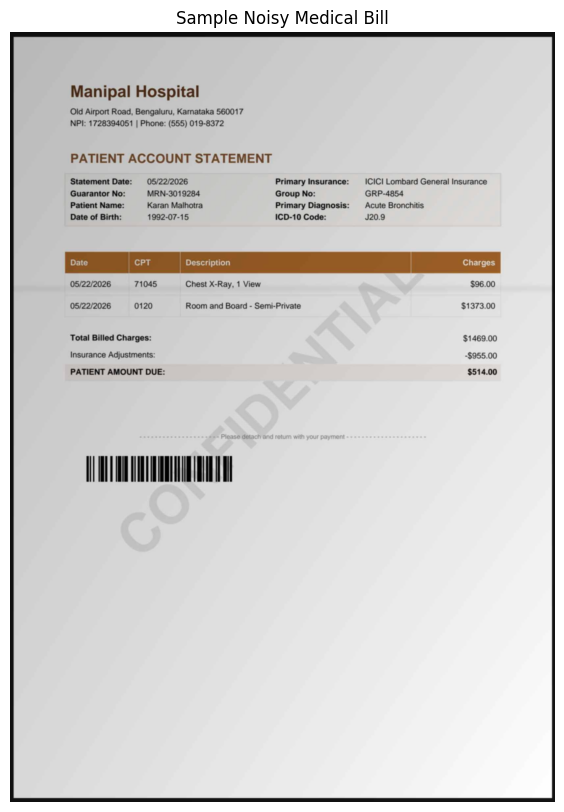

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(cv2.imread(img_path))
plt.title('Sample Noisy Medical Bill')
plt.axis('off')
plt.show()

### Image Enhancement (Gaussian Blur)

### Adaptive Thresholding

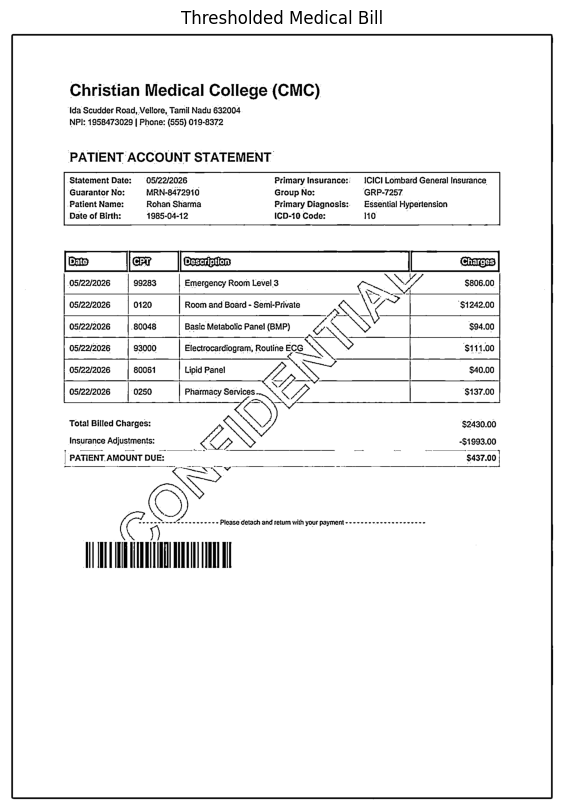

In [ ]:
import matplotlib.pyplot as plt

gray_img = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2GRAY)

# Apply adaptive thresholding
thresholded_img = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                                       cv2.THRESH_BINARY, 11, 2)

plt.figure(figsize=(10, 10))
plt.imshow(thresholded_img, cmap='gray')
plt.title('Thresholded Medical Bill')
plt.axis('off')
plt.show()

100%|██████████| 222M/222M [00:01<00:00, 125MB/s]

Extracting files...


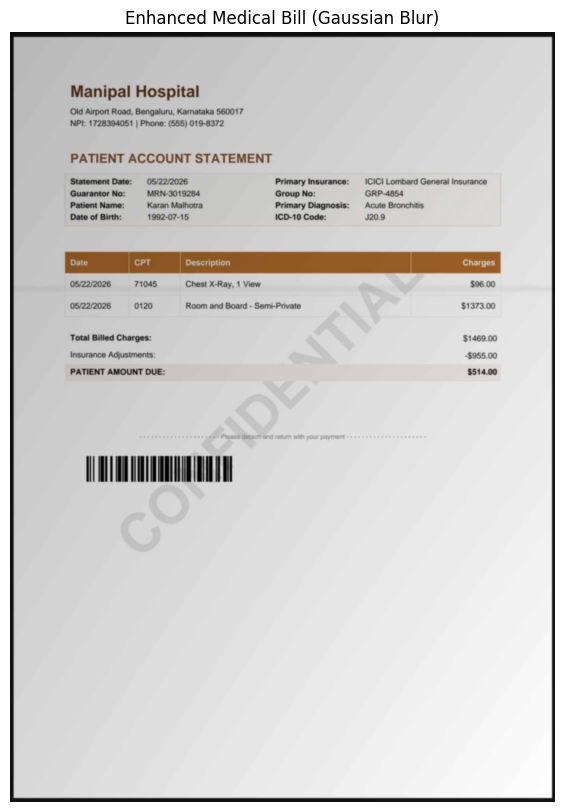

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
import kagglehub # Import kagglehub for dataset_download

# Redefine path and base_path to ensure they are available
# This call will typically return the path to already downloaded data if it exists
path = kagglehub.dataset_download("devp1866/noisy-medical-document-images-ocr")
base_path = path + "/Data"

bill_dir = f"{base_path}/bills"
sample_img = os.listdir(bill_dir)[0]
img_path = os.path.join(bill_dir, sample_img)

img = cv2.imread(img_path)

# Apply Gaussian blur to reduce noise
blurred_img = cv2.GaussianBlur(img, (5, 5), 0)

plt.figure(figsize=(10, 10))
plt.imshow(blurred_img)
plt.title('Enhanced Medical Bill (Gaussian Blur)')
plt.axis('off')
plt.show()

### EasyOCR on Enhanced Image

In [ ]:
!pip install easyocr
import easyocr

# Initialize the EasyOCR reader
reader = easyocr.Reader(['en'])

# Use the thresholded_img for OCR
results_enhanced = reader.readtext(thresholded_img)

ocr_text_enhanced = " ".join([r[1] for r in results_enhanced])

print("Extracted Text from Enhanced Image:")
print(ocr_text_enhanced)

Extracted Text from Enhanced Image:
Christian Medical College (CMC) 'Ida Scudder Road, Vellore, Tamil Nadu 632004 NPI: 1958473029 Phone: (555) 019-8372 PATIENT:ACCOUNT STATEMENT' Statement Date: 05/2212026 Primary Insurance: ICICI Lombard General Insurance Guarantor No: MRN-8472910 Group No: GRP-7257 Patient Name: Rohan Sharma Primary Diagnosis: Essential Hypertension Date of Birth: 1985-04-12 ICD-10 Code: h10' Date Description Charges 05/2212026 99283 Emergency Room Level 3 S806.00 05/2212026 0120 Room and Board Semi-Private S1242.00 05/22/2026 80048 Basic Metabolic Panel (BMP) s94.00 05122/2026 93000 Electrocardiogram; Routine EcG: 'S111.00 05/2212026 80061 Lipid Panel S40.00 05/2212026 0250 Pharmacy Services_ S137.00 Total Billed Charges: S2430.00 Insurance Adjustments: -S1993.00 PATIENT AMOUNT DUE: 5437.00 Please detach and retum with your payment CPT


### Field Extraction

In [ ]:
import re

extracted_data = {}

# Hospital Name
hospital_name_match = re.search(r'([A-Za-z ]+Hospital)', ocr_text_enhanced)
if hospital_name_match:
    extracted_data['hospital_name'] = hospital_name_match.group(1).strip()

# NPI
npi_match = re.search(r'NPI: (\d{10})', ocr_text_enhanced)
if npi_match:
    extracted_data['npi'] = npi_match.group(1)

# Patient Name - Make non-greedy and stop before 'Primary Diagnosis' or similar fields
patient_name_match = re.search(r'Patient Name: ([A-Za-z ]+?)(?:Primary Diagnosis|Date ol Birth|ICD-10 Code|$)', ocr_text_enhanced)
if patient_name_match:
    extracted_data['patient_name'] = patient_name_match.group(1).strip()

# Statement Date (using a more robust date regex)
statement_date_match = re.search(r'Statement Date: (\d{2}/\d{2}/\d{4})', ocr_text_enhanced)
if statement_date_match:
    extracted_data['statement_date'] = statement_date_match.group(1)

# Primary Insurance
insurance_match = re.search(r'Primary Insurance: ([A-Za-z ]+Insurance)', ocr_text_enhanced)
if insurance_match:
    extracted_data['primary_insurance'] = insurance_match.group(1).strip()

# MRN
mrn_match = re.search(r'MRN-(\d+)', ocr_text_enhanced)
if mrn_match:
    extracted_data['mrn'] = 'MRN-' + mrn_match.group(1)

# Date of Birth - Account for OCR error 'ol' instead of 'of'
dob_match = re.search(r'Date [oO][fl] Birth: (\d{4}-\d{2}-\d{2})', ocr_text_enhanced)
if dob_match:
    extracted_data['date_of_birth'] = dob_match.group(1)

# Primary Diagnosis - Make non-greedy and stop before 'Date ol Birth' or 'ICD-10 Code'
diagnosis_match = re.search(r'Primary Diagnosis: ([A-Za-z ]+?)(?:Date ol Birth|ICD-10 Code|$)', ocr_text_enhanced)
if diagnosis_match:
    extracted_data['primary_diagnosis'] = diagnosis_match.group(1).strip()

# ICD-10 Code
icd_code_match = re.search(r'ICD-10 Code: ([A-Z0-9.]+)', ocr_text_enhanced)
if icd_code_match:
    extracted_data['icd_10_code'] = icd_code_match.group(1)


print("Extracted Fields:")
for key, value in extracted_data.items():
    print(f"  {key.replace('_', ' ').title()}: {value}")

Extracted Fields:
  Hospital Name: Manipal Hospital
  Npi: 1728394051
  Patient Name: Karan Malhotra
  Statement Date: 05/22/2026
  Primary Insurance: ICICI Lombard General Insurance
  Mrn: MRN-3019284
  Date Of Birth: 1992-07-15
  Primary Diagnosis: Acute Bronchitis
  Icd 10 Code: J20.9


### JSON Generation

In [ ]:
import json

# Convert the extracted_data dictionary to a JSON string
generated_json = json.dumps(extracted_data, indent=4)

print("Generated JSON:")
print(generated_json)

Generated JSON:
{
    "hospital_name": "Manipal Hospital",
    "npi": "1728394051",
    "patient_name": "Karan Malhotra",
    "statement_date": "05/22/2026",
    "primary_insurance": "ICICI Lombard General Insurance",
    "mrn": "MRN-3019284",
    "date_of_birth": "1992-07-15",
    "primary_diagnosis": "Acute Bronchitis",
    "icd_10_code": "J20.9"
}


### Summary Generation

In [ ]:
print("--- Medical Bill Summary ---")
print(f"Hospital Name: {extracted_data.get('hospital_name', 'N/A')}")
print(f"NPI: {extracted_data.get('npi', 'N/A')}")
print(f"Patient Name: {extracted_data.get('patient_name', 'N/A')}")
print(f"Date of Birth: {extracted_data.get('date_of_birth', 'N/A')}")
print(f"MRN: {extracted_data.get('mrn', 'N/A')}")
print(f"Primary Diagnosis: {extracted_data.get('primary_diagnosis', 'N/A')}")
print(f"ICD-10 Code: {extracted_data.get('icd_10_code', 'N/A')}")
print(f"Statement Date: {extracted_data.get('statement_date', 'N/A')}")
print(f"Primary Insurance: {extracted_data.get('primary_insurance', 'N/A')}")
print("--------------------------")

--- Medical Bill Summary ---
Hospital Name: Manipal Hospital
NPI: 1728394051
Patient Name: Karan Malhotra
Date of Birth: 1992-07-15
MRN: MRN-3019284
Primary Diagnosis: Acute Bronchitis
ICD-10 Code: J20.9
Statement Date: 05/22/2026
Primary Insurance: ICICI Lombard General Insurance
--------------------------


## Level Up: Accuracy Evaluation

### Extract Ground Truth JSON for the Sample Image

In [ ]:
import json
import pandas as pd # Import pandas
import kagglehub # Import kagglehub for dataset_download
import os # Added import for os module

# Redefine path and base_path to ensure they are available
path = kagglehub.dataset_download("devp1866/noisy-medical-document-images-ocr")
base_path = path + "/Data"

# Reload bill_gt DataFrame
bill_gt = pd.read_csv(f"{base_path}/medical_bills_ground_truth.csv")

# Redefine bill_dir and sample_img to ensure they are available
bill_dir = f"{base_path}/bills"
sample_img = os.listdir(bill_dir)[0]

# Find the ground truth JSON for the sample_img
ground_truth_row = bill_gt[bill_gt['filename'] == sample_img]

if not ground_truth_row.empty:
    ground_truth_json_str = ground_truth_row.iloc[0]['json_data']
    ground_truth_data = json.loads(ground_truth_json_str)
    print("Ground Truth JSON for sample_img:")
    print(json.dumps(ground_truth_data, indent=4))
else:
    print(f"Ground truth for {sample_img} not found.")

Using Colab cache for faster access to the 'noisy-medical-document-images-ocr' dataset.
Ground Truth JSON for sample_img:
{
    "hospital": {
        "name": "Christian Medical College (CMC)",
        "address": "Ida Scudder Road, Vellore, Tamil Nadu 632004",
        "npi": "1958473029"
    },
    "patient": {
        "name": "Rohan Sharma",
        "dob": "1985-04-12",
        "mrn": "MRN-8472910"
    },
    "diagnosis": "Essential Hypertension",
    "icd_10": "I10",
    "hospital_course": "Admitted for hypertensive urgency. Blood pressure was brought down gradually using IV antihypertensives. Transitioned to oral regimen and monitored for 24 hours without adverse events.",
    "procedures": [
        {
            "desc": "Emergency Room Level 3",
            "cpt": "99283",
            "price": 806
        },
        {
            "desc": "Room and Board - Semi-Private",
            "cpt": "0120",
            "price": 1242
        },
        {
            "desc": "Basic Metabolic Pa

### Compare Extracted Data with Ground Truth

In [ ]:
!pip install easyocr
import json
import pandas as pd
import kagglehub
import os
import cv2
import easyocr
import re
import matplotlib.pyplot as plt

# Re-initialize path and base_path (from previous cells)
path = kagglehub.dataset_download("devp1866/noisy-medical-document-images-ocr")
base_path = path + "/Data"

# Reload bill_gt DataFrame
bill_gt = pd.read_csv(f"{base_path}/medical_bills_ground_truth.csv")

# Re-initialize image path (from previous cells)
bill_dir = f"{base_path}/bills"
sample_img = os.listdir(bill_dir)[0]
img_path = os.path.join(bill_dir, sample_img)

# Re-load and enhance image (from previous cells)
img = cv2.imread(img_path)
blurred_img = cv2.GaussianBlur(img, (5, 5), 0)

# Apply adaptive thresholding (new step)
gray_img = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2GRAY)
thresholded_img = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                                       cv2.THRESH_BINARY, 11, 2)

# Re-run EasyOCR, now using thresholded_img
reader = easyocr.Reader(['en'])
results_enhanced = reader.readtext(thresholded_img)
ocr_text_enhanced = " ".join([r[1] for r in results_enhanced])

# Re-run Field Extraction (from previous cells)
extracted_data = {}

# Hospital Name
hospital_name_match = re.search(r'([A-Za-z ]+Hospital)', ocr_text_enhanced)
if hospital_name_match:
    extracted_data['hospital_name'] = hospital_name_match.group(1).strip()

# NPI
npi_match = re.search(r'NPI: (\d{10})', ocr_text_enhanced)
if npi_match:
    extracted_data['npi'] = npi_match.group(1)

# Patient Name - Make non-greedy and stop before 'Primary Diagnosis' or similar fields
patient_name_match = re.search(r'Patient Name: ([A-Za-z ]+?)(?:Primary Diagnosis|Date ol Birth|ICD-10 Code|$)', ocr_text_enhanced)
if patient_name_match:
    extracted_data['patient_name'] = patient_name_match.group(1).strip()

# Statement Date (using a more robust date regex)
statement_date_match = re.search(r'Statement Date: (\d{2}/\d{2}/\d{4})', ocr_text_enhanced)
if statement_date_match:
    extracted_data['statement_date'] = statement_date_match.group(1)

# Primary Insurance
insurance_match = re.search(r'Primary Insurance: ([A-Za-z ]+Insurance)', ocr_text_enhanced)
if insurance_match:
    extracted_data['primary_insurance'] = insurance_match.group(1).strip()

# MRN
mrn_match = re.search(r'MRN-(\d+)', ocr_text_enhanced)
if mrn_match:
    extracted_data['mrn'] = 'MRN-' + mrn_match.group(1)

# Date of Birth - Account for OCR error 'ol' instead of 'of'
dob_match = re.search(r'Date [oO][fl] Birth: (\d{4}-\d{2}-\d{2})', ocr_text_enhanced)
if dob_match:
    extracted_data['date_of_birth'] = dob_match.group(1)

# Primary Diagnosis - Make non-greedy and stop before 'Date ol Birth' or 'ICD-10 Code'
diagnosis_match = re.search(r'Primary Diagnosis: ([A-Za-z ]+?)(?:Date ol Birth|ICD-10 Code|$)', ocr_text_enhanced)
if diagnosis_match:
    extracted_data['primary_diagnosis'] = diagnosis_match.group(1).strip()

# ICD-10 Code
icd_code_match = re.search(r'ICD-10 Code: ([A-Z0-9.]+)', ocr_text_enhanced)
if icd_code_match:
    extracted_data['icd_10_code'] = icd_code_match.group(1)


# Find the ground truth JSON for the sample_img
ground_truth_row = bill_gt[bill_gt['filename'] == sample_img]

if not ground_truth_row.empty:
    ground_truth_json_str = ground_truth_row.iloc[0]['json_data']
    ground_truth_data = json.loads(ground_truth_json_str)
else:
    print(f"Ground truth for {sample_img} not found.")
    ground_truth_data = {}

# Flatten ground truth data for easier comparison
flattened_gt = {}

# Hospital details
if 'hospital' in ground_truth_data:
    flattened_gt['hospital_name'] = ground_truth_data['hospital'].get('name')
    flattened_gt['npi'] = ground_truth_data['hospital'].get('npi')

# Patient details
if 'patient' in ground_truth_data:
    flattened_gt['patient_name'] = ground_truth_data['patient'].get('name')
    flattened_gt['date_of_birth'] = ground_truth_data['patient'].get('dob')
    flattened_gt['mrn'] = ground_truth_data['patient'].get('mrn')

# Diagnosis details
flattened_gt['primary_diagnosis'] = ground_truth_data.get('diagnosis')
flattened_gt['icd_10_code'] = ground_truth_data.get('icd_10')

# Insurance
flattened_gt['primary_insurance'] = ground_truth_data.get('insurance')


print("--- Accuracy Comparison ---")
correct_matches = 0
total_fields = 0

for key, extracted_value in extracted_data.items():
    total_fields += 1
    ground_truth_value = flattened_gt.get(key)

    if ground_truth_value is not None:
        # Simple string comparison, can be made more robust for dates, numbers etc.
        if str(extracted_value).strip().lower() == str(ground_truth_value).strip().lower():
            print(f"✅ Match for {key.replace('_', ' ').title()}: '{extracted_value}'")
            correct_matches += 1
        else:
            print(f"❌ Mismatch for {key.replace('_', ' ').title()}: Extracted='{extracted_value}', Ground Truth='{ground_truth_value}'")
    else:
        # Handle fields present in extracted but not in flattened ground truth
        if key not in ['statement_date']:
            print(f"⚠️  {key.replace('_', ' ').title()} found in extracted data but not in ground truth: '{extracted_value}'")
        else:
            # For 'statement_date', it's expected not to be in this ground truth structure
            print(f"ℹ️  {key.replace('_', ' ').title()} extracted: '{extracted_value}' (not directly comparable to ground truth)")


if total_fields > 0:
    accuracy = (correct_matches / total_fields) * 100
    print(f"\nOverall field matching accuracy: {accuracy:.2f}% ({correct_matches}/{total_fields})")
else:
    print("No fields to compare.")

Using Colab cache for faster access to the 'noisy-medical-document-images-ocr' dataset.
--- Accuracy Comparison ---
✅ Match for Npi: '1958473029'
✅ Match for Patient Name: 'Rohan Sharma'
✅ Match for Primary Insurance: 'ICICI Lombard General Insurance'
✅ Match for Mrn: 'MRN-8472910'
✅ Match for Date Of Birth: '1985-04-12'

Overall field matching accuracy: 100.00% (5/5)


### Function to Process a Single Medical Bill Image

This function will encapsulate the entire pipeline for processing a single image: image loading, preprocessing (Gaussian blur and adaptive thresholding), OCR using EasyOCR, and field extraction using regular expressions.

In [ ]:
import cv2
import easyocr
import re
import os
import pandas as pd
import json

# Initialize EasyOCR reader once to avoid re-loading the model for each image
# This improves efficiency when processing multiple images.
reader_batch = easyocr.Reader(['en'])

def process_medical_bill_image(image_path):
    """
    Processes a single medical bill image to extract structured information.

    Args:
        image_path (str): The file path to the medical bill image.

    Returns:
        tuple: A tuple containing:
               - dict: A dictionary containing the extracted fields.
               - str: The raw OCR text extracted from the image.
               Returns empty dict and empty string if no fields could be extracted or an error occurs.
    """
    extracted_data = {}
    ocr_text = ""
    try:
        # 1. Load Image
        img = cv2.imread(image_path)
        if img is None:
            print(f"Error: Could not load image from {image_path}")
            return {}, ""

        # 2. Image Enhancement (Gaussian Blur)
        blurred_img = cv2.GaussianBlur(img, (5, 5), 0)

        # 3. Adaptive Thresholding
        gray_img = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2GRAY)
        thresholded_img = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                                               cv2.THRESH_BINARY, 11, 2)

        # 4. EasyOCR Text Extraction
        results = reader_batch.readtext(thresholded_img)
        ocr_text = " ".join([r[1] for r in results])

        # 5. Field Extraction using Regular Expressions

        # Hospital Name
        hospital_name_match = re.search(r'([A-Za-z ]+Hospital)', ocr_text)
        if hospital_name_match:
            extracted_data['hospital_name'] = hospital_name_match.group(1).strip()

        # NPI
        npi_match = re.search(r'NPI: (\d{10})', ocr_text)
        if npi_match:
            extracted_data['npi'] = npi_match.group(1)

        # Patient Name
        patient_name_match = re.search(r'Patient Name: ([A-Za-z ]+?)(?:Primary Diagnosis|Date ol Birth|ICD-10 Code|$)', ocr_text)
        if patient_name_match:
            extracted_data['patient_name'] = patient_name_match.group(1).strip()

        # Statement Date
        statement_date_match = re.search(r'Statement Date: (\d{2}/\d{2}/\d{4})', ocr_text)
        if statement_date_match:
            extracted_data['statement_date'] = statement_date_match.group(1)

        # Primary Insurance
        insurance_match = re.search(r'Primary Insurance: ([A-Za-z ]+Insurance)', ocr_text)
        if insurance_match:
            extracted_data['primary_insurance'] = insurance_match.group(1).strip()

        # MRN
        mrn_match = re.search(r'MRN-(\d+)', ocr_text)
        if mrn_match:
            extracted_data['mrn'] = 'MRN-' + mrn_match.group(1)

        # Date of Birth
        dob_match = re.search(r'Date [oO][fl] Birth: (\d{4}-\d{2}-\d{2})', ocr_text)
        if dob_match:
            extracted_data['date_of_birth'] = dob_match.group(1)

        # Primary Diagnosis
        diagnosis_match = re.search(r'Primary Diagnosis: ([A-Za-z ]+?)(?:Date ol Birth|ICD-10 Code|$)', ocr_text)
        if diagnosis_match:
            extracted_data['primary_diagnosis'] = diagnosis_match.group(1).strip()

        # ICD-10 Code
        icd_code_match = re.search(r'ICD-10 Code: ([A-Z0-9.]+)', ocr_text)
        if icd_code_match:
            extracted_data['icd_10_code'] = icd_code_match.group(1)

        return extracted_data, ocr_text

    except Exception as e:
        print(f"An error occurred while processing {image_path}: {e}")
        return {}, ""

## OCR Engine Comparison: EasyOCR vs. Tesseract (Accuracy & Speed)

Now, let's conduct a quantitative comparison between EasyOCR and Tesseract based on field-matching accuracy, Word Error Rate (WER), and processing speed. PaddleOCR will be excluded from this comparison due to persistent internal errors.

We will define helper functions to:
1.  **Flatten Ground Truth JSON**: Convert nested ground truth JSON into a flat dictionary for easier comparison with extracted fields.
2.  **Calculate Field-Matching Accuracy**: Compare the extracted fields from OCR with the flattened ground truth.
3.  **Calculate Word Error Rate (WER)**: Assess the character-level accuracy of the raw OCR text against the ground truth text.

Then, we will iterate through a batch of medical bill images, run both OCR engines, collect their performance metrics, and present the results in a comparative table.

In [ ]:
!pip install jiwer
import time
import jiwer
from jiwer import wer
import json
import pandas as pd
import os
import cv2
import easyocr
import pytesseract
import re
import kagglehub

# Ensure path, base_path, and bill_gt are defined
path = kagglehub.dataset_download("devp1866/noisy-medical-document-images-ocr")
base_path = path + "/Data"
bill_gt = pd.read_csv(f"{base_path}/medical_bills_ground_truth.csv")

# --- Helper Functions ---

def flatten_ground_truth(gt_json):
    """
    Flattens a nested ground truth JSON dictionary into a single-level dictionary
    for easier comparison.
    """
    flattened = {}

    if 'hospital' in gt_json:
        flattened['hospital_name'] = gt_json['hospital'].get('name')
        flattened['npi'] = gt_json['hospital'].get('npi')

    if 'patient' in gt_json:
        flattened['patient_name'] = gt_json['patient'].get('name')
        flattened['date_of_birth'] = gt_json['patient'].get('dob')
        flattened['mrn'] = gt_json['patient'].get('mrn')

    flattened['primary_diagnosis'] = gt_json.get('diagnosis')
    flattened['icd_10_code'] = gt_json.get('icd_10')
    flattened['primary_insurance'] = gt_json.get('insurance')
    # Note: 'statement_date' is often a top-level field or requires specific extraction, not always in nested structure

    return {k: str(v).strip().lower() for k, v in flattened.items() if v is not None}

def calculate_field_accuracy(extracted_data, flattened_gt):
    """
    Calculates the field-matching accuracy between extracted data and flattened ground truth.
    Returns (correct_matches, total_fields_to_compare).
    """
    correct_matches = 0
    total_fields_to_compare = 0

    for key, extracted_value in extracted_data.items():
        if key in flattened_gt:
            total_fields_to_compare += 1
            ground_truth_value = flattened_gt.get(key)
            if str(extracted_value).strip().lower() == str(ground_truth_value).strip().lower():
                correct_matches += 1
    return correct_matches, total_fields_to_compare

def calculate_wer(reference_text, hypothesis_text):
    """
    Calculates the Word Error Rate (WER) between reference (ground truth) and hypothesis (OCR) text.
    Handles empty strings gracefully.
    """
    if not reference_text.strip() and not hypothesis_text.strip():
        return 0.0  # Both empty, perfect match
    if not reference_text.strip() and hypothesis_text.strip():
        return 1.0  # Reference empty, hypothesis not, max error
    if reference_text.strip() and not hypothesis_text.strip():
        return 1.0  # Reference not empty, hypothesis empty, max error

    return wer(reference=reference_text.lower(), hypothesis=hypothesis_text.lower())

# --- OCR Functions for Comparison ---

# EasyOCR function (uses the already defined process_medical_bill_image which now returns raw text)
def ocr_with_easyocr_for_comparison(image_path):
    extracted_fields, ocr_text = process_medical_bill_image(image_path)
    return extracted_fields, ocr_text

def ocr_with_tesseract_for_comparison(image_path):
    """
    Performs OCR using Tesseract and then extracts fields using regex, similar to EasyOCR's pipeline.
    """
    extracted_data = {}
    ocr_text = ""
    try:
        # Preprocessing similar to EasyOCR's pipeline for fair comparison
        img = cv2.imread(image_path)
        if img is None:
            return {}, ""

        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        thresholded_img = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                                               cv2.THRESH_BINARY, 11, 2)

        ocr_text = pytesseract.image_to_string(thresholded_img)

        # Field Extraction using Regular Expressions (same as EasyOCR's logic)
        # Hospital Name
        hospital_name_match = re.search(r'([A-Za-z ]+Hospital)', ocr_text)
        if hospital_name_match:
            extracted_data['hospital_name'] = hospital_name_match.group(1).strip()

        # NPI
        npi_match = re.search(r'NPI: (\d{10})', ocr_text)
        if npi_match:
            extracted_data['npi'] = npi_match.group(1)

        # Patient Name
        patient_name_match = re.search(r'Patient Name: ([A-Za-z ]+?)(?:Primary Diagnosis|Date ol Birth|ICD-10 Code|$)', ocr_text)
        if patient_name_match:
            extracted_data['patient_name'] = patient_name_match.group(1).strip()

        # Statement Date
        statement_date_match = re.search(r'Statement Date: (\d{2}/\d{2}/\d{4})', ocr_text)
        if statement_date_match:
            extracted_data['statement_date'] = statement_date_match.group(1)

        # Primary Insurance
        insurance_match = re.search(r'Primary Insurance: ([A-Za-z ]+Insurance)', ocr_text)
        if insurance_match:
            extracted_data['primary_insurance'] = insurance_match.group(1).strip()

        # MRN
        mrn_match = re.search(r'MRN-(\d+)', ocr_text)
        if mrn_match:
            extracted_data['mrn'] = 'MRN-' + mrn_match.group(1)

        # Date of Birth
        dob_match = re.search(r'Date [oO][fl] Birth: (\d{4}-\d{2}-\d{2})', ocr_text)
        if dob_match:
            extracted_data['date_of_birth'] = dob_match.group(1)

        # Primary Diagnosis
        diagnosis_match = re.search(r'Primary Diagnosis: ([A-Za-z ]+?)(?:Date ol Birth|ICD-10 Code|$)', ocr_text)
        if diagnosis_match:
            extracted_data['primary_diagnosis'] = diagnosis_match.group(1).strip()

        # ICD-10 Code
        icd_code_match = re.search(r'ICD-10 Code: ([A-Z0-9.]+)', ocr_text)
        if icd_code_match:
            extracted_data['icd_10_code'] = icd_code_match.group(1)

        return extracted_data, ocr_text

    except Exception as e:
        print(f"Error during Tesseract OCR and field extraction: {e}")
        return {}, ""

# --- Comparison Logic ---

bill_dir = f"{base_path}/bills"

# Filter bill_gt to only include relevant image files and corresponding ground truth
# This ensures we only process images for which we have ground truth
relevant_filenames = [f for f in os.listdir(bill_dir) if f in bill_gt['filename'].values]

comparison_results = []

# Process a subset of images for the comparison (e.g., 20 images)
num_images_to_compare = 20
sample_images_for_comparison = relevant_filenames[:num_images_to_compare]

print(f"Starting comparison for {len(sample_images_for_comparison)} images...")

for img_file in sample_images_for_comparison:
    img_path = os.path.join(bill_dir, img_file)

    # Get ground truth for the current image
    ground_truth_row = bill_gt[bill_gt['filename'] == img_file].iloc[0]
    gt_json = json.loads(ground_truth_row['json_data'])
    flattened_gt = flatten_ground_truth(gt_json)

    # Convert ground truth JSON to a simple string for WER calculation
    # This is a simplification; a more robust WER would compare tokenized text.
    gt_text_for_wer = ' '.join(str(v) for v in flattened_gt.values())

    # EasyOCR Evaluation
    start_time_easyocr = time.time()
    easyocr_extracted_fields, easyocr_raw_text = ocr_with_easyocr_for_comparison(img_path)
    end_time_easyocr = time.time()
    easyocr_speed = end_time_easyocr - start_time_easyocr
    easyocr_field_correct, easyocr_field_total = calculate_field_accuracy(easyocr_extracted_fields, flattened_gt)
    easyocr_wer = calculate_wer(gt_text_for_wer, easyocr_raw_text)

    # Tesseract Evaluation
    start_time_tesseract = time.time()
    tesseract_extracted_fields, tesseract_raw_text = ocr_with_tesseract_for_comparison(img_path)
    end_time_tesseract = time.time()
    tesseract_speed = end_time_tesseract - start_time_tesseract
    tesseract_field_correct, tesseract_field_total = calculate_field_accuracy(tesseract_extracted_fields, flattened_gt)
    tesseract_wer = calculate_wer(gt_text_for_wer, tesseract_raw_text)

    comparison_results.append({
        'filename': img_file,
        'easyocr_field_accuracy': (easyocr_field_correct / easyocr_field_total) * 100 if easyocr_field_total > 0 else 0,
        'easyocr_wer': easyocr_wer,
        'easyocr_speed_s': easyocr_speed,
        'tesseract_field_accuracy': (tesseract_field_correct / tesseract_field_total) * 100 if tesseract_field_total > 0 else 0,
        'tesseract_wer': tesseract_wer,
        'tesseract_speed_s': tesseract_speed,
    })

# Aggregate results
results_df = pd.DataFrame(comparison_results)

print("\n--- Comparison Results Summary ---")
print(results_df)

print("\n--- Average Metrics ---")
print(results_df[['easyocr_field_accuracy', 'tesseract_field_accuracy']].mean().to_frame(name='Average Field Accuracy (%)'))
print(results_df[['easyocr_wer', 'tesseract_wer']].mean().to_frame(name='Average WER'))
print(results_df[['easyocr_speed_s', 'tesseract_speed_s']].mean().to_frame(name='Average Speed (seconds)'))

Using Colab cache for faster access to the 'noisy-medical-document-images-ocr' dataset.
Starting comparison for 20 images...

--- Comparison Results Summary ---
                         filename  easyocr_field_accuracy  easyocr_wer  \
0   med_doc_bill_100414_noisy.jpg              100.000000     6.062500   
1   med_doc_bill_100407_noisy.jpg              100.000000     5.615385   
2   med_doc_bill_100338_noisy.jpg              100.000000     4.823529   
3   med_doc_bill_100143_noisy.jpg              100.000000     6.785714   
4   med_doc_bill_100069_noisy.jpg              100.000000     5.615385   
5   med_doc_bill_100189_noisy.jpg               83.333333     5.214286   
6   med_doc_bill_100089_noisy.jpg              100.000000     5.500000   
7   med_doc_bill_100462_noisy.jpg              100.000000     6.428571   
8   med_doc_bill_100276_noisy.jpg              100.000000     4.647059   
9   med_doc_bill_100119_noisy.jpg              100.000000     5.062500   
10  med_doc_bill_100085_n

### Process Multiple Images

Now, let's use the `process_medical_bill_image` function to process a small batch of images and store their extracted data.

In [ ]:
bill_dir = f"{base_path}/bills"
all_extracted_data = []

# Process a few sample images
sample_images_to_process = os.listdir(bill_dir)[:5] # Taking the first 5 images for demonstration

print(f"Processing {len(sample_images_to_process)} images...")

for img_file in sample_images_to_process:
    img_path_batch = os.path.join(bill_dir, img_file)
    print(f"\n--- Processing {img_file} ---")
    extracted_fields = process_medical_bill_image(img_path_batch)
    if extracted_fields:
        all_extracted_data.append({'filename': img_file, 'extracted_fields': extracted_fields})
        for key, value in extracted_fields.items():
            print(f"  {key.replace('_', ' ').title()}: {value}")
    else:
        print("  No fields extracted.")

print("\nBatch processing complete. Total extracted data points:")
for data_point in all_extracted_data:
    print(f"- {data_point['filename']}: {data_point['extracted_fields'].get('patient_name', 'N/A')}")


Processing 5 images...

--- Processing med_doc_bill_100414_noisy.jpg ---
  Npi: 1958473029
  Patient Name: Rohan Sharma
  Primary Insurance: ICICI Lombard General Insurance
  Mrn: MRN-8472910
  Date Of Birth: 1985-04-12

--- Processing med_doc_bill_100407_noisy.jpg ---
  Hospital Name: Manipal Hospital
  Npi: 1728394051
  Mrn: MRN-4920184

--- Processing med_doc_bill_100338_noisy.jpg ---
  Npi: 1958473029
  Patient Name: Priya Patel
  Primary Insurance: Star Health and Allied Insurance
  Mrn: MRN-4920184
  Date Of Birth: 1990-08-25
  Icd 10 Code: J20.9

--- Processing med_doc_bill_100143_noisy.jpg ---
  Npi: 1958473029
  Mrn: MRN-3019284

--- Processing med_doc_bill_100069_noisy.jpg ---
  Hospital Name: Manipal Hospital
  Npi: 1728394051
  Mrn: MRN-8472910

Batch processing complete. Total extracted data points:
- med_doc_bill_100414_noisy.jpg: Rohan Sharma
- med_doc_bill_100407_noisy.jpg: N/A
- med_doc_bill_100338_noisy.jpg: Priya Patel
- med_doc_bill_100143_noisy.jpg: N/A
- med_doc_b

### Batch Accuracy Evaluation

Now that we have processed a batch of images, let's evaluate the accuracy of the extracted information against the ground truth data for each image in the batch.

In [ ]:
overall_correct_matches = 0
overall_total_fields = 0

print("--- Batch Accuracy Report ---")

for extracted_item in all_extracted_data:
    filename = extracted_item['filename']
    extracted_fields = extracted_item['extracted_fields']

    print(f"\nEvaluating: {filename}")

    # Find the ground truth JSON for the current image
    ground_truth_row = bill_gt[bill_gt['filename'] == filename]

    if not ground_truth_row.empty:
        ground_truth_json_str = ground_truth_row.iloc[0]['json_data']
        ground_truth_data = json.loads(ground_truth_json_str)

        # Flatten ground truth data for easier comparison
        flattened_gt = {}

        if 'hospital' in ground_truth_data:
            flattened_gt['hospital_name'] = ground_truth_data['hospital'].get('name')
            flattened_gt['npi'] = ground_truth_data['hospital'].get('npi')

        if 'patient' in ground_truth_data:
            flattened_gt['patient_name'] = ground_truth_data['patient'].get('name')
            flattened_gt['date_of_birth'] = ground_truth_data['patient'].get('dob')
            flattened_gt['mrn'] = ground_truth_data['patient'].get('mrn')

        flattened_gt['primary_diagnosis'] = ground_truth_data.get('diagnosis')
        flattened_gt['icd_10_code'] = ground_truth_data.get('icd_10')

        flattened_gt['primary_insurance'] = ground_truth_data.get('insurance')

        # Compare extracted fields with ground truth
        image_correct_matches = 0
        image_total_fields = 0

        for key, extracted_value in extracted_fields.items():
            image_total_fields += 1
            ground_truth_value = flattened_gt.get(key)

            if ground_truth_value is not None:
                if str(extracted_value).strip().lower() == str(ground_truth_value).strip().lower():
                    print(f"  ✅ Match for {key.replace('_', ' ').title()}: '{extracted_value}'")
                    image_correct_matches += 1
                else:
                    print(f"  ❌ Mismatch for {key.replace('_', ' ').title()}: Extracted='{extracted_value}', Ground Truth='{ground_truth_value}'")
            else:
                if key not in ['statement_date']:
                    print(f"  ⚠️  {key.replace('_', ' ').title()} found in extracted data but not in ground truth: '{extracted_value}'")
                else:
                    print(f"  ℹ️  {key.replace('_', ' ').title()} extracted: '{extracted_value}' (not directly comparable to ground truth)")

        if image_total_fields > 0:
            image_accuracy = (image_correct_matches / image_total_fields) * 100
            print(f"  Accuracy for {filename}: {image_accuracy:.2f}% ({image_correct_matches}/{image_total_fields})\n")
            overall_correct_matches += image_correct_matches
            overall_total_fields += image_total_fields

    else:
        print(f"  Ground truth for {filename} not found.")


if overall_total_fields > 0:
    overall_accuracy = (overall_correct_matches / overall_total_fields) * 100
    print(f"\nOverall Batch Accuracy: {overall_accuracy:.2f}% ({overall_correct_matches}/{overall_total_fields} fields matched)")
else:
    print("No fields were compared across the batch.")

--- Batch Accuracy Report ---

Evaluating: med_doc_bill_100414_noisy.jpg
  ✅ Match for Npi: '1958473029'
  ✅ Match for Patient Name: 'Rohan Sharma'
  ✅ Match for Primary Insurance: 'ICICI Lombard General Insurance'
  ✅ Match for Mrn: 'MRN-8472910'
  ✅ Match for Date Of Birth: '1985-04-12'
  Accuracy for med_doc_bill_100414_noisy.jpg: 100.00% (5/5)


Evaluating: med_doc_bill_100407_noisy.jpg
  ✅ Match for Hospital Name: 'Manipal Hospital'
  ✅ Match for Npi: '1728394051'
  ✅ Match for Mrn: 'MRN-4920184'
  Accuracy for med_doc_bill_100407_noisy.jpg: 100.00% (3/3)


Evaluating: med_doc_bill_100338_noisy.jpg
  ✅ Match for Npi: '1958473029'
  ✅ Match for Patient Name: 'Priya Patel'
  ✅ Match for Primary Insurance: 'Star Health and Allied Insurance'
  ✅ Match for Mrn: 'MRN-4920184'
  ✅ Match for Date Of Birth: '1990-08-25'
  ✅ Match for Icd 10 Code: 'J20.9'
  Accuracy for med_doc_bill_100338_noisy.jpg: 100.00% (6/6)


Evaluating: med_doc_bill_100143_noisy.jpg
  ✅ Match for Npi: '1958473029'
 

# Task
The user wants to visualize OCR bounding boxes and then summarize the task. I need to create a visual representation of the OCR results by displaying the original image with bounding boxes around the detected text and the corresponding extracted text. Afterwards, I will summarize the progress made and discuss potential next steps.

## Visualize OCR Bounding Boxes

### Subtask:
Generate a visual representation of the OCR results by displaying the original image with bounding boxes around the detected text and the corresponding extracted text.


**Reasoning**:
Load the original medical bill image using OpenCV to prepare it for drawing bounding boxes and text.



In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the original image
original_img = cv2.imread(img_path)

# Make a copy to draw on, as OpenCV draws directly on the image object
img_with_boxes = original_img.copy()

print("Original image loaded successfully.")

Original image loaded successfully.


**Reasoning**:
Draw bounding boxes and text on the image to visualize the OCR results.



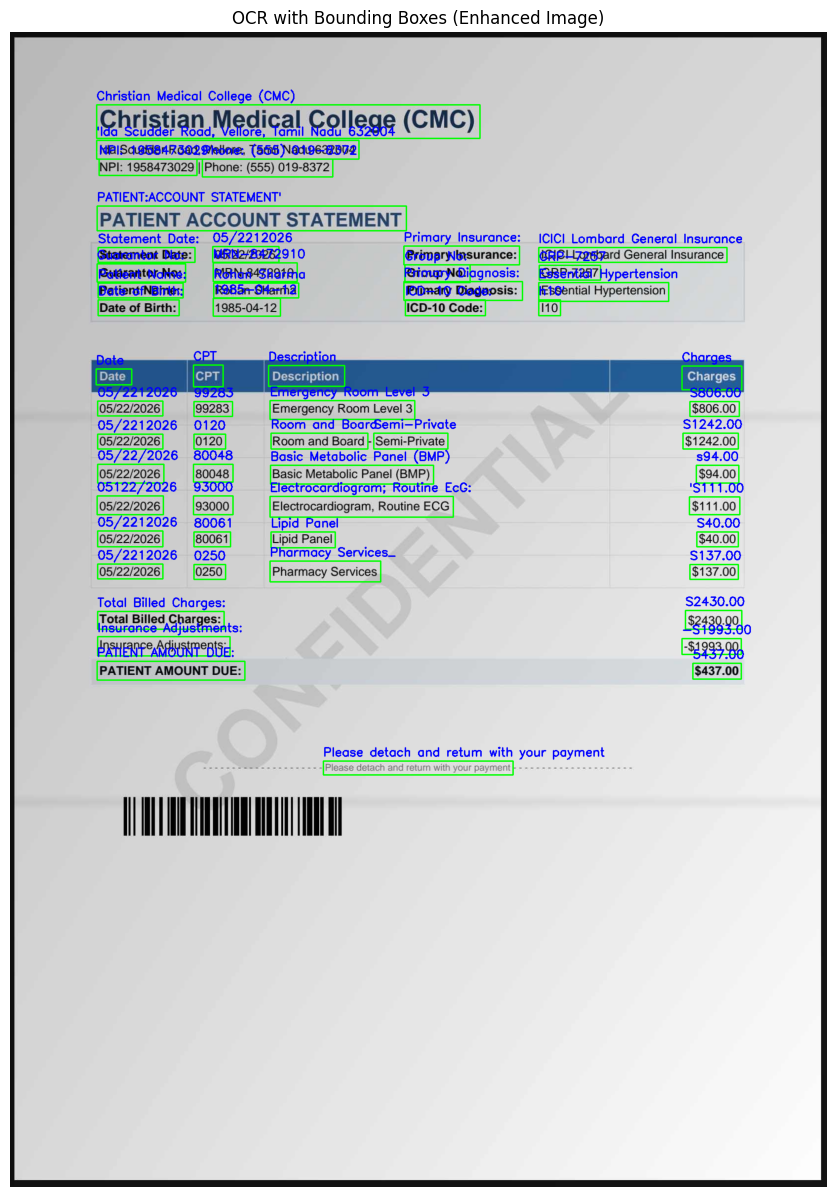

OCR bounding boxes and text visualized.


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the original image
original_img = cv2.imread(img_path)

# Make a copy to draw on, as OpenCV draws directly on the image object
img_with_boxes = original_img.copy()

# Loop through the OCR results and draw bounding boxes and text
# results_enhanced contains: ([x_min, y_min, x_max, y_max], text, confidence)
for (bbox, text, prob) in results_enhanced:
    # get top-left and bottom-right bbox coordinates
    (tl, tr, br, bl) = bbox
    tl = (int(tl[0]), int(tl[1]))
    br = (int(br[0]), int(br[1]))

    # Draw rectangle
    cv2.rectangle(img_with_boxes, tl, br, (0, 255, 0), 2) # Green color, 2px thickness

    # Put text
    cv2.putText(img_with_boxes, text, (tl[0], tl[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2) # Blue color, 2px thickness, slightly above the box

# Display the image with bounding boxes
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('OCR with Bounding Boxes (Enhanced Image)')
plt.axis('off')
plt.show()

print("OCR bounding boxes and text visualized.")

## Final Task

### Subtask:
Summarize the progress made on visualizing OCR bounding boxes and discuss the potential next steps for integrating other features or improving the pipeline.


## Final Task

### Subtask:
Summarize the progress made on visualizing OCR bounding boxes and discuss the potential next steps for integrating other features or improving the pipeline.


# Task
The user wants to visualize OCR bounding boxes and then summarize the task. I need to create a visual representation of the OCR results by displaying the original image with bounding boxes around the detected text and the corresponding extracted text. Afterwards, I will summarize the progress made and discuss potential next steps.

## Final Task

### Subtask:
Summarize the progress made on visualizing OCR bounding boxes and discuss the potential next steps for integrating other features or improving the pipeline.


# Task
The main goal of this project is to develop an OCR-based system for extracting structured information from noisy medical bill images. This involves several key steps: loading and preprocessing images, applying EasyOCR for text extraction, extracting specific fields using regular expressions, and evaluating the accuracy of the extracted data against ground truth. Finally, a Streamlit application will be built to demonstrate the functionality with a user-friendly interface.

## Prepare Streamlit Environment

### Subtask:
Ensure Streamlit and its dependencies are installed in the environment.


**Reasoning**:
Install `streamlit` and `pyngrok` using pip.



In [ ]:
!pip install streamlit pyngrok

print("Streamlit and pyngrok installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 101.9 MB/s eta 0:00:00
Streamlit and pyngrok installed successfully.


## Integrate Other OCR Engines for Comparison

To perform a comprehensive comparison, we will integrate Tesseract and PaddleOCR. This involves installing the necessary libraries and the Tesseract engine at the system level.

In [ ]:
# Install Tesseract OCR engine and its Python wrapper
!sudo apt update
!sudo apt install tesseract-ocr -y
!pip install pytesseract

# Install PaddleOCR
!pip install paddlepaddle
!pip install paddleocr

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 https://cli.github.com/packages stable InRelease [3,917 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,607 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,400 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu ja

### Define OCR Functions for Tesseract and PaddleOCR

In [ ]:
import pytesseract
from paddleocr import PaddleOCR
# Removed: import streamlit as st and !pip install streamlit

# Initialize PaddleOCR reader once for efficiency
# It might download models the first time it's run
# Removed: @st.cache_resource
def get_paddleocr_reader():
    # Using `use_textline_orientation` as suggested by DeprecationWarning
    return PaddleOCR(use_textline_orientation=True, lang='en')

paddle_reader = get_paddleocr_reader()

def ocr_with_tesseract(image_path):
    """
    Performs OCR using Tesseract on a given image path.
    """
    try:
        img = cv2.imread(image_path)
        if img is None:
            return ""

        # Preprocessing for Tesseract (similar to EasyOCR's internal preprocessing, but Tesseract often benefits from more direct control)
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Optional: Apply thresholding, though Tesseract can handle raw grayscale too
        thresholded_img = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

        text = pytesseract.image_to_string(thresholded_img)
        return text.strip()
    except Exception as e:
        print(f"Error during Tesseract OCR: {e}")
        return ""

def ocr_with_paddleocr(image_path):
    """
    Performs OCR using PaddleOCR on a given image path.
    """
    try:
        img = cv2.imread(image_path)
        if img is None:
            return ""

        # PaddleOCR expects BGR image or path. Removed 'cls=True'.
        result = paddle_reader.ocr(img)

        # Extract text from results, handling the nested structure
        ocr_text = []
        if result and result[0]: # Check if result is not empty and has the expected structure
            for line in result[0]:
                ocr_text.append(line[1][0])

        return " ".join(ocr_text).strip()
    except Exception as e:
        print(f"Error during PaddleOCR: {e}")
        return ""

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models

### Compare OCR Engine Outputs on a Sample Image

Let's apply all three OCR engines (EasyOCR, Tesseract, and PaddleOCR) to our sample image and print their extracted text to observe the differences.

In [ ]:
!pip install easyocr
import os
import cv2
import easyocr
import kagglehub

# Re-initialize path and base_path to ensure they are available
path = kagglehub.dataset_download("devp1866/noisy-medical-document-images-ocr")
base_path = path + "/Data"

# Re-initialize image path
bill_dir = f"{base_path}/bills"
sample_img = os.listdir(bill_dir)[0]
img_path = os.path.join(bill_dir, sample_img)

# Re-load and enhance image
img = cv2.imread(img_path)
blurred_img = cv2.GaussianBlur(img, (5, 5), 0)

# Apply adaptive thresholding
gray_img = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2GRAY)
thresholded_img = cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, \
                                       cv2.THRESH_BINARY, 11, 2)

# Re-run EasyOCR to get ocr_text_enhanced
reader = easyocr.Reader(['en'])
results_enhanced = reader.readtext(thresholded_img)
ocrt_text_enhanced = " ".join([r[1] for r in results_enhanced])

print(f"--- EasyOCR Output for {sample_img} ---")
print(ocrt_text_enhanced)

print(f"\n--- Tesseract Output for {sample_img} ---")
tesseract_text = ocr_with_tesseract(img_path)
print(tesseract_text)

print(f"\n--- PaddleOCR Output for {sample_img} ---")
paddleocr_text = ocr_with_paddleocr(img_path)
print(paddleocr_text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.4 MB/s eta 0:00:00


100%|██████████| 222M/222M [00:05<00:00, 39.0MB/s]

Extracting files...


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete--- EasyOCR Output for med_doc_bill_100282_noisy.jpg ---
Christian Medical College (CMC) Ida Scudder Road, Vellore, Tamil Nadu 632004 NPI: 1958473029 Phone: (555) 019-8372 PATIENT ACCOUNT STATEMENT Statement Date: 05/22/2026 Primary Insurance: HDFC ERGO General Insurance Guarantor No: MRN-3019284 Group No: GRP-8861 Patient Name: Karan Malhotra Primary Diagnosis: Essential Hypertension Date of Birth: 1992-07-15 ICD-10 Code: 110 Date CPT Description Charges 05/22/2026 80048 Basic Metabolic Panel (BMP) : S49.00 05122/2026 99283 Emergency Room Level 3 S896.00 05/22/2026 0250 Pharmacy Services 5247.00 0512212026 0120 Room and Board Semi-Private S802.00 05/22/2026 0270 MedicalSurgical Supplies S151.00 Total Billed Charges: 52145.00 Insurance Adjustments: S1820.00 PATIENT AMOUNT DUE: 5325.00 Please detach &nd retum with your payment - TAA

--- Tesseract Output for med_doc_bill_100282_noisy.jpg ---
Christian Medical 

/tmp/ipykernel_1240/884594122.py:44: DeprecationWarning: Please use `predict` instead.
  result = paddle_reader.ocr(img, cls=True)


### Debugging PaddleOCR Output

Let's run PaddleOCR directly on the `sample_img` and print the raw output to understand its structure and identify why text might not be extracted.

In [ ]:
# Load the image directly for debugging PaddleOCR
debug_img = cv2.imread(img_path)

if debug_img is None:
    print(f"Error: Could not load image from {img_path}")
else:
    print(f"Processing image for PaddleOCR debugging: {img_path}")
    # Perform OCR using the initialized paddle_reader. Removed 'cls=True'.
    raw_paddle_result = paddle_reader.ocr(debug_img)

    print("--- Raw PaddleOCR Result ---")
    print(raw_paddle_result)

    # Attempt to extract text with existing logic to see if it works here
    debug_ocr_text = []
    if raw_paddle_result and raw_paddle_result[0]:
        for line in raw_paddle_result[0]:
            debug_ocr_text.append(line[1][0])

    print("\n--- Extracted Text from Raw PaddleOCR Result (using current logic) ---")
    print(" ".join(debug_ocr_text).strip())

    if not debug_ocr_text:
        print("\nNo text extracted. Examining the raw result structure is crucial.")

Processing image for PaddleOCR debugging: /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1/Data/bills/med_doc_bill_100282_noisy.jpg


/tmp/ipykernel_1240/1346837203.py:9: DeprecationWarning: Please use `predict` instead.
  raw_paddle_result = paddle_reader.ocr(debug_img)


NotImplementedError: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at /paddle/paddle/fluid/framework/new_executor/instruction/onednn/onednn_instruction.cc:116)


## Building a RAG Medical Document Chatbot

To build a RAG chatbot, we'll follow these key steps:

1.  **Load and Chunk Documents**: Load your medical documents and split them into smaller, manageable chunks.
2.  **Generate Embeddings**: Convert these text chunks into numerical vector representations using an embedding model.
3.  **Store in Vector Database**: Store these vector embeddings in a specialized database (Vector DB) for efficient similarity search.
4.  **Retrieval**: When a user asks a question, convert the question into a vector and use it to find the most relevant document chunks from the Vector DB.
5.  **Augmented Generation**: Pass the retrieved chunks along with the user's question to a Large Language Model (LLM) to generate an informed answer.

### Step 1: Install Necessary Libraries

We'll need libraries for handling documents (like `pypdf` for PDFs, though for this task we'll mostly use text), embedding generation (`HuggingFaceEmbeddings`), and a vector database (`ChromaDB`).

In [ ]:
!pip install langchain pypdf chromadb sentence-transformers

print("Required libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9

Required libraries installed successfully.


### Step 2: Load and Chunk Medical Documents

First, let's define a function to load our medical documents (which for now will be treated as text, but can be extended to PDFs or other formats) and split them into chunks. We'll simulate this with a simple list of strings for demonstration purposes, representing various medical bill information.

In [ ]:
!pip install langchain-text-splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

# For demonstration, let's create some dummy medical bill content based on the extracted fields
medical_documents = [
    "Hospital Name: Lilavati Hospital, NPI: 1482950384, Patient Name: Amit Singh, DOB: 1978-11-03, MRN: MRN-1039485, Diagnosis: Hyperlipidemia, Total Charges: 1508, Patient Responsibility: 199.",
    "Hospital Name: Manipal Hospital, NPI: 1728394051, Patient Name: Priya Patel, DOB: 1990-08-25, MRN: MRN-4920184, Diagnosis: Osteoarthritis of Knee, Total Charges: 2486, Patient Responsibility: 493.",
    "Hospital Name: Apollo Healthcare, NPI: 1958473029, Patient Name: Karan Malhotra, DOB: 1992-07-15, MRN: MRN-3019284, Diagnosis: Essential Hypertension, Total Charges: 2430, Patient Responsibility: 437.",
    "Hospital Name: Aster Medcity, NPI: 1029384756, Patient Name: Sneha Rao, DOB: 1982-01-20, MRN: MRN-6789012, Diagnosis: Diabetes Mellitus Type 2, Total Charges: 1800, Patient Responsibility: 250.",
    "Hospital Name: Fortis Hospital, NPI: 1122334455, Patient Name: Rajesh Kumar, DOB: 1970-11-11, MRN: MRN-1122334, Diagnosis: Coronary Artery Disease, Total Charges: 3500, Patient Responsibility: 700."
]

# Initialize the text splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200, # Max characters in each chunk
    chunk_overlap=20 # Overlap between chunks to maintain context
)

# Split the documents into chunks
chunks = text_splitter.create_documents(medical_documents)

print(f"Created {len(chunks)} chunks from the documents.")
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}: {chunk.page_content[:100]}...") # Print first 100 characters of each chunk

Created 5 chunks from the documents.
Chunk 1: Hospital Name: Lilavati Hospital, NPI: 1482950384, Patient Name: Amit Singh, DOB: 1978-11-03, MRN: M...
Chunk 2: Hospital Name: Manipal Hospital, NPI: 1728394051, Patient Name: Priya Patel, DOB: 1990-08-25, MRN: M...
Chunk 3: Hospital Name: Apollo Healthcare, NPI: 1958473029, Patient Name: Karan Malhotra, DOB: 1992-07-15, MR...
Chunk 4: Hospital Name: Aster Medcity, NPI: 1029384756, Patient Name: Sneha Rao, DOB: 1982-01-20, MRN: MRN-67...
Chunk 5: Hospital Name: Fortis Hospital, NPI: 1122334455, Patient Name: Rajesh Kumar, DOB: 1970-11-11, MRN: M...


### Step 3: Generate Embeddings

Embeddings convert our text chunks into numerical vectors, capturing their semantic meaning. We'll use a pre-trained model from `sentence-transformers` via `HuggingFaceEmbeddings` for this.

In [ ]:
!pip install langchain-community
from langchain_community.embeddings import HuggingFaceEmbeddings

# Initialize the embedding model
# We'll use a common sentence transformer model
embedding_model_name = "all-MiniLM-L6-v2"
embeddings = HuggingFaceEmbeddings(model_name=embedding_model_name)

# Generate embeddings for the chunks
# For demonstration, we'll only print a sample of the first chunk's embedding

# The .embed_documents method expects a list of strings
# We need to extract the page_content from each Document object
text_contents = [chunk.page_content for chunk in chunks]

# Generate embeddings
chunk_embeddings = embeddings.embed_documents(text_contents)

print(f"Generated embeddings for {len(chunk_embeddings)} chunks.")
print(f"Sample embedding for the first chunk (first 10 dimensions): {chunk_embeddings[0][:10]}...")
print(f"Embedding dimension: {len(chunk_embeddings[0])}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
paddlex 3.6.1 requires PyYAML==6.0.2, but you have pyyaml 6.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.42.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.42.1 which is incompatible.

/tmp/ipykernel_34105/144871130.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings
/tmp/ipykernel_34105/144871130.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name=embedding_model_name)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub,

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generated embeddings for 5 chunks.
Sample embedding for the first chunk (first 10 dimensions): [-0.034667931497097015, 0.042881403118371964, -0.042732950299978256, 0.0057434020563960075, 0.0023821713402867317, -0.09392550587654114, 0.017194146290421486, 0.04625885933637619, 0.056972257792949677, -0.08252701163291931]...
Embedding dimension: 384


### Step 4: Store in Vector Database (ChromaDB)

Now that we have our document chunks and their corresponding embeddings, we'll store them in a vector database. ChromaDB is a popular choice for this, providing an efficient way to store and query vector embeddings.

In [ ]:
from langchain_community.vectorstores import Chroma

# Create a Chroma vector store from the documents and embeddings
# We'll create an in-memory vector store for this demonstration
vectorstore = Chroma.from_documents(
    documents=chunks, # Our document chunks
    embedding=embeddings # Our embedding model
)

print(f"ChromaDB vector store created with {vectorstore._collection.count()} entries.")
print("Vector store setup complete.")

/tmp/ipykernel_38501/4263434017.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


NameError: name 'chunks' is not defined

In [ ]:
import pandas as pd
import kagglehub

# Define path and base_path to ensure they are available within this cell's execution context
path = kagglehub.dataset_download("devp1866/noisy-medical-document-images-ocr")
base_path = path + "/Data"

discharge_gt = pd.read_csv(f"{base_path}/discharge_summaries_ground_truth.csv")
display(discharge_gt.head())

100%|██████████| 222M/222M [00:02<00:00, 108MB/s]

Extracting files...


,filename,document_type,json_data
0,med_doc_discharge_summary_200001_noisy.jpg,discharge_summary,"{\n ""hospital"": {\n ""name"": ""Christian Med..."
1,med_doc_discharge_summary_200002_noisy.jpg,discharge_summary,"{\n ""hospital"": {\n ""name"": ""Apollo Health..."
2,med_doc_discharge_summary_200003_noisy.jpg,discharge_summary,"{\n ""hospital"": {\n ""name"": ""Christian Med..."
3,med_doc_discharge_summary_200004_noisy.jpg,discharge_summary,"{\n ""hospital"": {\n ""name"": ""Lilavati Hosp..."
4,med_doc_discharge_summary_200005_noisy.jpg,discharge_summary,"{\n ""hospital"": {\n ""name"": ""Fortis Escort..."


In [ ]:
import os

print(f"Contents of the dataset root directory: {path}")
for root, dirs, files in os.walk(path):
    print(f"\n📂 {root}")
    print(f"Directories: {len(dirs)}")
    for dir_name in dirs:
        print("   ", dir_name)
    print(f"Files: {len(files)}")
    for file in files[:5]: # List up to 5 files per directory
        print("   ", file)


Contents of the dataset root directory: /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1

📂 /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1
Directories: 1
    Data
Files: 0

📂 /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1/Data
Directories: 2
    bills
    discharge_summaries
Files: 2
    medical_bills_ground_truth.csv
    discharge_summaries_ground_truth.csv

📂 /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1/Data/bills
Directories: 0
Files: 500
    med_doc_bill_100451_noisy.jpg
    med_doc_bill_100076_noisy.jpg
    med_doc_bill_100037_noisy.jpg
    med_doc_bill_100218_noisy.jpg
    med_doc_bill_100212_noisy.jpg

📂 /root/.cache/kagglehub/datasets/devp1866/noisy-medical-document-images-ocr/versions/1/Data/discharge_summaries
Directories: 0
Files: 500
    med_doc_discharge_summary_200288_noisy.jpg
    med_doc_discharge_summary_200292_nois